Following this YT Video: https://www.youtube.com/watch?v=UuTkioxL9bQ&list=PL_Ke9hJMFeR9Kos7VtiPPiPp9Y16sA7Ef&index=11

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Optimal Policy:
{'Rainy': 'Umbrella', 'Cloudy': 'Umbrella', 'Sunny': 'No Umbrella'}


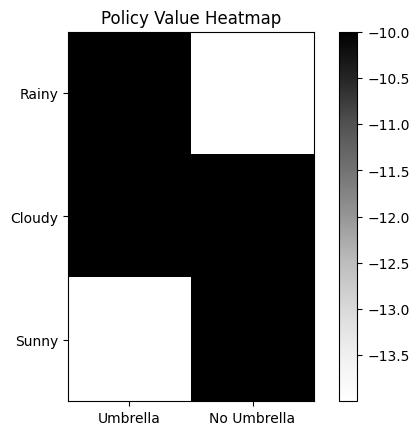

In [9]:
import numpy as np
import matplotlib.pyplot as plt

states = ['Rainy', 'Cloudy', 'Sunny']
actions = ['Umbrella', 'No Umbrella']

rewards = {
    'Rainy': {'Umbrella': -1, 'No Umbrella': -5},
    'Cloudy': {'Umbrella': -1, 'No Umbrella': -1},
    'Sunny': {'Umbrella': -5, 'No Umbrella': -1},
}
# transition[s][a][s2] : P(s' | s,a): probability of going to next state s2 from s using action a

transition = {  # If the current state is Rainy and choose action umbrella, then there is 70% that the next state will be Rainy, 30% of being cloudy, and 0% chance of being sunny. 
    'Rainy': {
        'Umbrella': {'Rainy': 0.7, 'Cloudy': 0.3, 'Sunny': 0},
        'No Umbrella': {'Rainy': 0.3, 'Cloudy': 0.4, 'Sunny': 0.3}
    },
    'Cloudy': {
        'Umbrella': {'Rainy': 0.7, 'Cloudy': 0.3, 'Sunny': 0},
        'No Umbrella': {'Rainy': 0.3, 'Cloudy': 0.4, 'Sunny': 0.3}
    },
    'Sunny': {
        'Umbrella': {'Rainy': 0.7, 'Cloudy': 0.3, 'Sunny': 0},
        'No Umbrella': {'Rainy': 0.3, 'Cloudy': 0.4, 'Sunny': 0.3}
    }
}

discount_factor = 0.9


# Value Iteration

def value_iteration():
    V = {s: 0 for s in states}   #Initialize value function:  V(s)=0 for all states

    while True:   # Infinite loop until convergence 
        new_V = {}   # Temporary storage for updated values Vnew

        for s in states:   # Loop over each state s
            values = []   # Store value of each action Q(s,a)

            for a in actions:   # Loop over actions 
                value = rewards[s][a]  # Start with immediate reward: R(s,a)

                for s2 in states:  # Loop over all possible next states
                    value += discount_factor * transition[s][a][s2] * V[s2]

                values.append(value)  # Store Q(s,a)

            new_V[s] = max(values)

        # convergence check
        if all(abs(V[s] - new_V[s]) < 1e-4 for s in states):  # assuming epsilon = 1e-4
            return new_V   # stop when stable → optimal values found

        V = new_V  # Update values for next iteration 


V = value_iteration()


# Optimal Policy
policy = {}  # store optimal action for each state 

for s in states:  # Loop states
    values = []  # store action values 

    for a in actions:   # Start with R(s,a)
        value = rewards[s][a]

        for s2 in states:   # Add expected future value
            value += discount_factor * transition[s][a][s2] * V[s2]

        values.append(value)

    policy[s] = actions[np.argmax(values)]   # Choose action with max value

print("Optimal Policy:")
print(policy)


# Plot
policy_values = np.zeros((len(states), len(actions)))  # rows are states, columns are actions 

for i, s in enumerate(states):
    for j, a in enumerate(actions):
        policy_values[i, j] = rewards[s][a] + discount_factor * sum(
            transition[s][a][s2] * V[s2] for s2 in states
        )

plt.imshow(policy_values, cmap='Greys')
plt.colorbar()
plt.xticks(range(len(actions)), actions)
plt.yticks(range(len(states)), states)
plt.title("Policy Value Heatmap")
plt.show()

Value Iteration
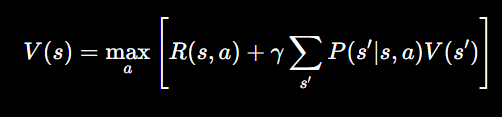

Optimal policy
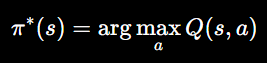